In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import math

from common import (
    CASE_NAMES,
    get_dataset_sort_key,
    INDEX_ORDER,
    index_colors,
    index_hatches,
    transform_duckdb_index_name,
    transform_pgvector_index_name,
    apply_style,
    save_fig,
    format_dataset_label,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    X_TICK_FONTSIZE,
    BAR_LABEL_FONTSIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
    BAR_TEXT_COLOR,
)

# ---------------------------------------------------------------------------
# 1. Load all result JSONs from both DuckDB and pgvector directories
# ---------------------------------------------------------------------------
records = []

# Load DuckDB results
duckdb_results_dir = pathlib.Path("../experiments/results/index_creation/DuckDB")
duckdb_json_files = sorted(duckdb_results_dir.glob("*.json"))

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Parse db_label JSON to get global_version
        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)

        index_name = transform_duckdb_index_name(db_case_cfg, global_version)

        records.append({
            "optimize_duration": metrics["optimize_duration"],
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "threads": db_cfg["duckdb_threads"],
            "global_version": global_version,
            "db_type": "DuckDB",
        })

# Load pgvector results
pgvector_results_dir = pathlib.Path("../experiments/results/index_creation/PgVector")
pgvector_json_files = sorted(pgvector_results_dir.glob("*.json"))

for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        index_name = transform_pgvector_index_name(db_case_cfg)

        # pgvector uses max_parallel_workers in db_case_config instead of duckdb_threads in db_config
        threads = db_case_cfg.get("max_parallel_workers", None)

        records.append({
            "optimize_duration": metrics["optimize_duration"],
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "threads": threads,
            "global_version": None,  # pgvector doesn't have global_version
            "db_type": "PgVector",
        })

print(f"Loaded {len(records)} results from {len(duckdb_json_files)} DuckDB files and {len(pgvector_json_files)} pgvector files")
records[:3]

Loaded 210 results from 150 DuckDB files and 60 pgvector files


[{'optimize_duration': 6.2874,
  'index': 'DuckDB PDXearch (IVF, Row Group, F32)',
  'case_id': 502,
  'threads': 1,
  'global_version': None,
  'db_type': 'DuckDB'},
 {'optimize_duration': 6.4479,
  'index': 'DuckDB PDXearch (IVF, Row Group, U8)',
  'case_id': 502,
  'threads': 1,
  'global_version': None,
  'db_type': 'DuckDB'},
 {'optimize_duration': 2.6699,
  'index': 'DuckDB PDXearch (IVF, Row Group, F32)',
  'case_id': 502,
  'threads': 14,
  'global_version': None,
  'db_type': 'DuckDB'}]

In [2]:
# ---------------------------------------------------------------------------
# 2. Case ID → human-readable dataset name
# ---------------------------------------------------------------------------

for r in records:
    r["dataset"] = CASE_NAMES.get(r["case_id"], f"Unknown (case_id={r['case_id']})")

unique_datasets = set(r["dataset"] for r in records)
datasets = sorted(unique_datasets, key=get_dataset_sort_key)

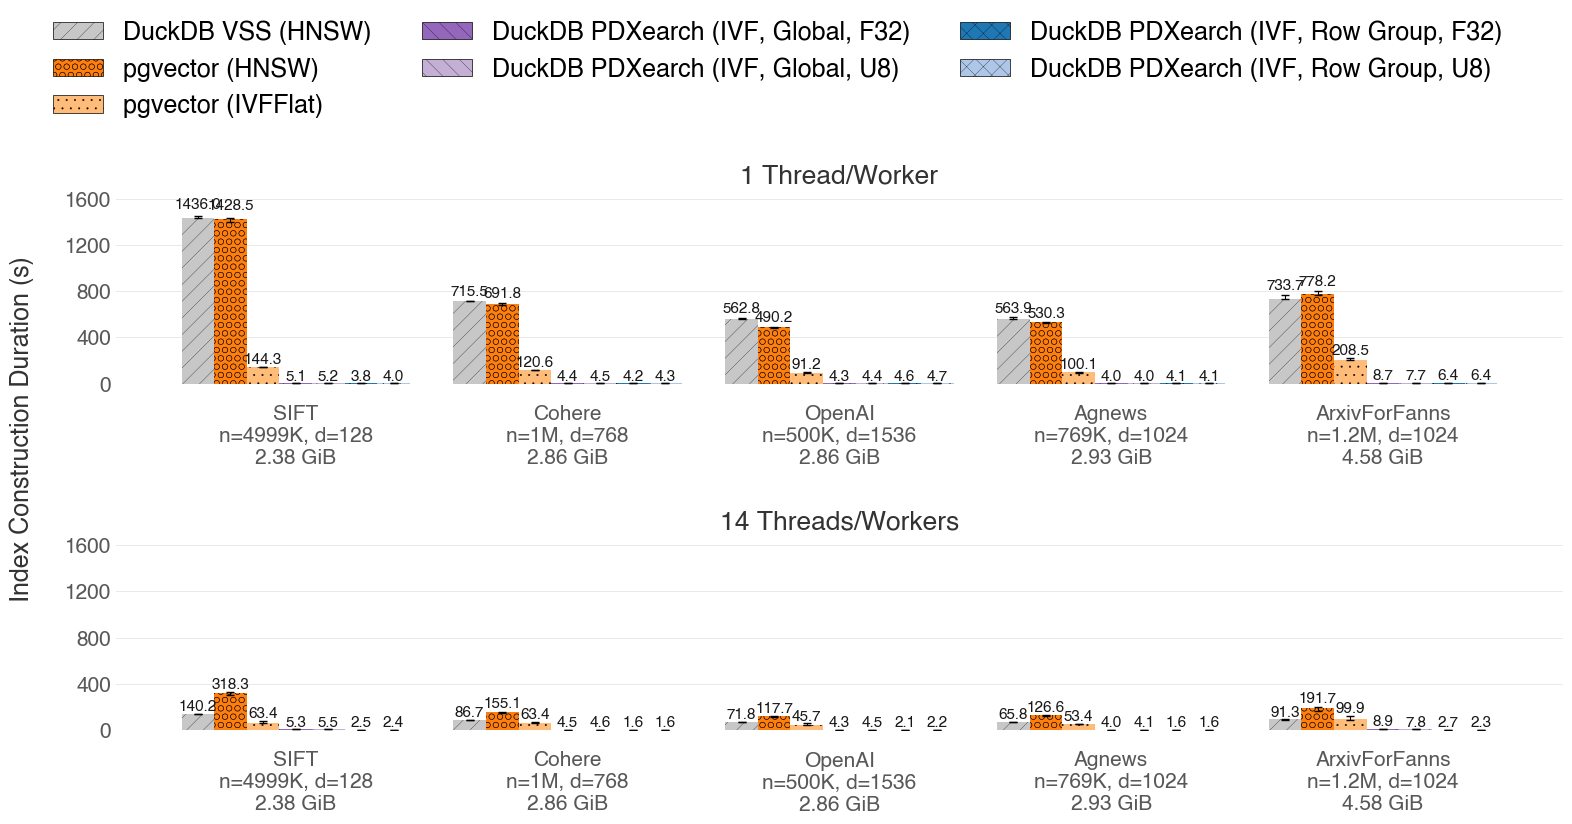

In [3]:
# ---------------------------------------------------------------------------
# 3. Plot: one subplot per dataset, bars grouped by (index, threads, global_version)
# ---------------------------------------------------------------------------
from collections import defaultdict
import re
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

apply_style()

# Group records: dataset → thread_count → index_type → list of durations
grouped: dict[str, dict[int, dict[str, list[float]]]] = {
    ds: {1: defaultdict(list), 14: defaultdict(list)} for ds in datasets
}

for r in records:
    threads = r["threads"]
    if threads is not None:
        grouped[r["dataset"]][threads][r["index"]].append(r["optimize_duration"])

# Get all unique index types across all datasets and thread counts
all_index_types = set()
for dataset in datasets:
    for threads in [1, 14]:
        all_index_types.update(grouped[dataset][threads].keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]
n_index_types = len(all_index_types)

# Create 2 subplots: one for 1T, one for 14T (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharey=False)
axes = axes.flatten()  # Flatten to make indexing easier

bar_width = 0.45  # Width of each bar
group_width = n_index_types * bar_width + 0.2  # Total width of a dataset group
group_spacing = 0.4  # Space between dataset groups

# First, collect all durations from graph 1 (1 Thread/Worker) to determine shared y-axis limits
graph1_tops = []
for dataset in datasets:
    thread_data = grouped[dataset][1]
    for index_type in all_index_types:
        durations = thread_data.get(index_type, [])
        if durations:
            med_dur = float(np.median(durations))

            lo_err = med_dur - float(np.min(durations))

            hi_err = float(np.max(durations)) - med_dur
            graph1_tops.append(max(durations))

# Calculate shared y-axis limit from graph 1
if graph1_tops:
    shared_max_y = max(graph1_tops) * 1.15
else:
    shared_max_y = 100

for ax_idx, target_threads in enumerate([1, 14]):
    ax = axes[ax_idx]
    x_base = 0
    x_labels = []

    for dataset in datasets:
        thread_data = grouped[dataset][target_threads]

        # Skip if no data for this thread count
        if not any(thread_data.values()):
            continue

        group_start = x_base
        for idx_idx, index_type in enumerate(all_index_types):
            x = group_start + idx_idx * bar_width

            durations = thread_data.get(index_type, [])
            if durations:
                med_dur = float(np.median(durations))

                lo_err = med_dur - float(np.min(durations))

                hi_err = float(np.max(durations)) - med_dur
                color = index_colors.get(index_type, "#808080")
                hatch = index_hatches.get(index_type, "")
                ax.bar(x, med_dur, bar_width, yerr=[[lo_err], [hi_err]], color=color, hatch=hatch,
                       capsize=3, error_kw={"linewidth": 0.8},
                       label=index_type if dataset == datasets[0] else "")

                # Add value label on top of bar + error bar with offset
                top = med_dur + hi_err
                offset = max(0.05, top * 0.03)
                ax.text(x, top + offset, f"{med_dur:.1f}",
                       ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE, color=BAR_TEXT_COLOR)

        # Use detailed dataset label for x-axis
        dataset_label = format_dataset_label(dataset)
        x_labels.append(dataset_label)
        x_base += group_width + group_spacing

    # Set title (singular when 1)
    label = "Thread/Worker" if target_threads == 1 else "Threads/Workers"
    ax.set_title(f"{target_threads} {label}", fontsize=LABEL_FONTSIZE + 1, color=FONT_COLOR)

    ax.set_ylabel("")

    # Set x-ticks at the center of each dataset group
    group_centers = []
    x_base = 0
    for dataset in datasets:
        if any(grouped[dataset][target_threads].values()):
            center = x_base + (n_index_types - 1) * bar_width / 2
            group_centers.append(center)
            x_base += group_width + group_spacing

    ax.set_xticks(group_centers)
    ax.set_xticklabels(x_labels, fontsize=X_TICK_FONTSIZE, color=TICK_FONTS_COLOR)

    # Grids (horizontal only)
    ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)

    # Spine adjustments (remove top and right)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Y-axis limits and locator (use same limits as graph 1)
    ax.set_ylim(0, shared_max_y)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.tick_params(axis='y', colors=TICK_FONTS_COLOR, labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='both', length=0)
    ax.tick_params(axis='x', pad=15)  # Increase spacing between x-axis labels and axis

# Shared legend - create handles for all index types
legend_handles = []
legend_labels = []
for index_type in all_index_types:
    color = index_colors.get(index_type, "#808080")
    hatch = index_hatches.get(index_type, "")
    legend_handles.append(Patch(facecolor=color, hatch=hatch, edgecolor='black', linewidth=0.5))
    legend_labels.append(index_type)

fig.legend(legend_handles, legend_labels, loc="upper center", ncols=math.ceil(len(all_index_types) / 3),
          frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.04))

fig.supylabel("Index Construction Duration (s)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR)
fig.tight_layout(rect=[0.02, 0, 1, 0.85])
fig.subplots_adjust(hspace=0.80)
# plt.show()
save_fig("index_creation")

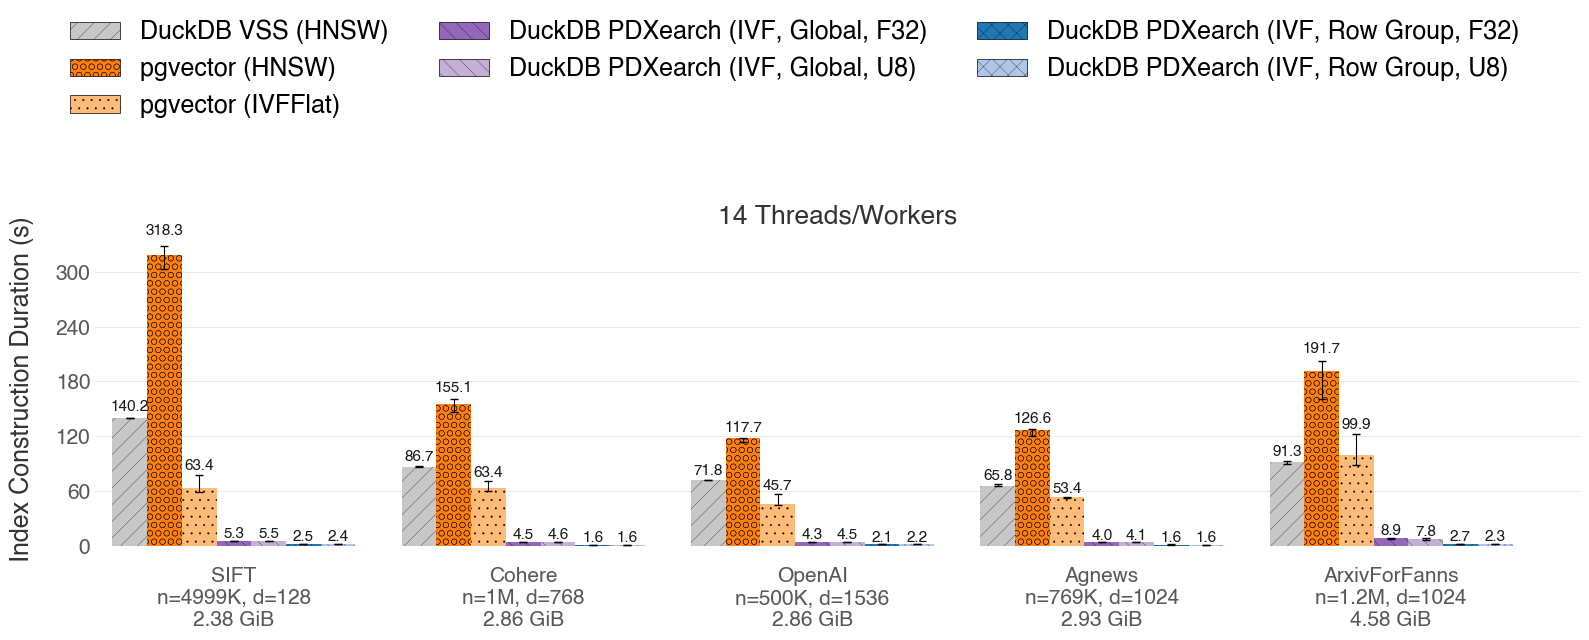

In [4]:
# ---------------------------------------------------------------------------
# 3b. Plot: 14 Threads/Workers only — one subplot per dataset
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch

apply_style()

TARGET_THREADS = 14

# Group records: dataset → index_type → list of durations (14 threads only)
grouped_14t: dict[str, dict[str, list[float]]] = {
    ds: defaultdict(list) for ds in datasets
}

for r in records:
    if r["threads"] == TARGET_THREADS:
        grouped_14t[r["dataset"]][r["index"]].append(r["optimize_duration"])

# Get all unique index types present in the 14-thread data
all_index_types_14t = set()
for dataset in datasets:
    all_index_types_14t.update(grouped_14t[dataset].keys())
all_index_types_14t = [idx for idx in INDEX_ORDER if idx in all_index_types_14t]
n_index_types = len(all_index_types_14t)

bar_width = 0.45
group_width = n_index_types * bar_width + 0.2
group_spacing = 0.4

fig, ax = plt.subplots(1, 1, figsize=(16, 6))

x_base = 0
x_labels = []
group_centers = []

for dataset in datasets:
    thread_data = grouped_14t[dataset]
    if not any(thread_data.values()):
        continue

    group_start = x_base
    for idx_idx, index_type in enumerate(all_index_types_14t):
        x = group_start + idx_idx * bar_width
        durations = thread_data.get(index_type, [])
        if durations:
            med_dur = float(np.median(durations))

            lo_err = med_dur - float(np.min(durations))

            hi_err = float(np.max(durations)) - med_dur
            color = index_colors.get(index_type, "#808080")
            hatch = index_hatches.get(index_type, "")
            ax.bar(x, med_dur, bar_width, yerr=[[lo_err], [hi_err]], color=color, hatch=hatch,
                   capsize=3, error_kw={"linewidth": 0.8})

            top = med_dur + hi_err
            offset = max(0.05, top * 0.03)
            ax.text(x, top + offset, f"{med_dur:.1f}",
                    ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE, color=BAR_TEXT_COLOR)

    dataset_label = format_dataset_label(dataset)
    x_labels.append(dataset_label)
    center = group_start + (n_index_types - 1) * bar_width / 2
    group_centers.append(center)
    x_base += group_width + group_spacing

ax.set_title(f"{TARGET_THREADS} Threads/Workers", fontsize=LABEL_FONTSIZE + 1, color=FONT_COLOR)
ax.set_ylabel("Index Construction Duration (s)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

ax.set_xticks(group_centers)
ax.set_xticklabels(x_labels, fontsize=X_TICK_FONTSIZE, color=TICK_FONTS_COLOR)

# Tighten x-axis margins around the bar groups
ax.set_xlim(-bar_width, x_base - group_spacing + bar_width)

ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_major_locator(MultipleLocator(60))
ax.tick_params(axis='y', colors=TICK_FONTS_COLOR, labelsize=TICK_FONTSIZE)
ax.tick_params(axis='both', length=0)
ax.tick_params(axis='x', pad=15)

# Legend
legend_handles = [
    Patch(facecolor=index_colors.get(idx, "#808080"),
          hatch=index_hatches.get(idx, ""),
          edgecolor='black', linewidth=0.5, label=idx)
    for idx in all_index_types_14t
]
fig.legend(handles=legend_handles, loc="upper center", ncols=math.ceil(len(all_index_types_14t) / 3),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.08))

fig.tight_layout(rect=[0, 0, 1, 0.76])
save_fig("index_creation_14t")

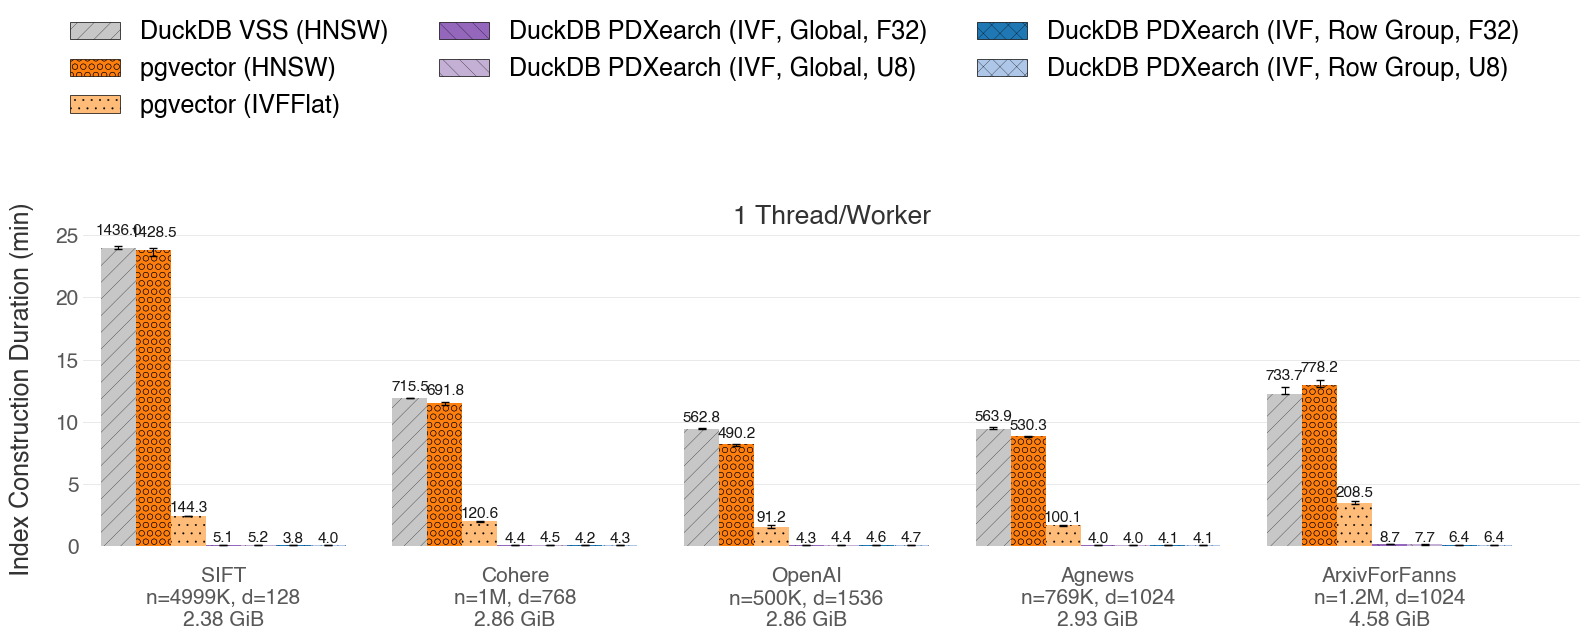

In [5]:
# ---------------------------------------------------------------------------
# 3c. Plot: 1 Thread/Worker only — y-axis in minutes
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.patches import Patch

apply_style()

TARGET_THREADS = 1

# Group records: dataset → index_type → list of durations (1 thread only)
grouped_1t: dict[str, dict[str, list[float]]] = {
    ds: defaultdict(list) for ds in datasets
}

for r in records:
    if r["threads"] == TARGET_THREADS:
        grouped_1t[r["dataset"]][r["index"]].append(r["optimize_duration"])

# Get all unique index types present in the 1-thread data
all_index_types_1t = set()
for dataset in datasets:
    all_index_types_1t.update(grouped_1t[dataset].keys())
all_index_types_1t = [idx for idx in INDEX_ORDER if idx in all_index_types_1t]
n_index_types = len(all_index_types_1t)

bar_width = 0.45
group_width = n_index_types * bar_width + 0.2
group_spacing = 0.4

fig, ax = plt.subplots(1, 1, figsize=(16, 6))

x_base = 0
x_labels = []
group_centers = []

for dataset in datasets:
    thread_data = grouped_1t[dataset]
    if not any(thread_data.values()):
        continue

    group_start = x_base
    for idx_idx, index_type in enumerate(all_index_types_1t):
        x = group_start + idx_idx * bar_width
        durations = thread_data.get(index_type, [])
        if durations:
            med_dur = float(np.median(durations))

            lo_err = med_dur - float(np.min(durations))

            hi_err = float(np.max(durations)) - med_dur
            color = index_colors.get(index_type, "#808080")
            hatch = index_hatches.get(index_type, "")
            ax.bar(x, med_dur / 60, bar_width, yerr=[[lo_err / 60], [hi_err / 60]], color=color, hatch=hatch,
                   capsize=3, error_kw={"linewidth": 0.8})

            top = (med_dur + hi_err) / 60
            offset = max(0.01, top * 0.03)
            ax.text(x, top + offset, f"{med_dur:.1f}",
                    ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE, color=BAR_TEXT_COLOR)

    dataset_label = format_dataset_label(dataset)
    x_labels.append(dataset_label)
    center = group_start + (n_index_types - 1) * bar_width / 2
    group_centers.append(center)
    x_base += group_width + group_spacing

ax.set_title(f"{TARGET_THREADS} Thread/Worker", fontsize=LABEL_FONTSIZE + 1, color=FONT_COLOR)
ax.set_ylabel("Index Construction Duration (min)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

ax.set_xticks(group_centers)
ax.set_xticklabels(x_labels, fontsize=X_TICK_FONTSIZE, color=TICK_FONTS_COLOR)

# Tighten x-axis margins around the bar groups
ax.set_xlim(-bar_width, x_base - group_spacing + bar_width)

ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(axis='y', colors=TICK_FONTS_COLOR, labelsize=TICK_FONTSIZE)
ax.tick_params(axis='both', length=0)
ax.tick_params(axis='x', pad=15)

# Legend
legend_handles = [
    Patch(facecolor=index_colors.get(idx, "#808080"),
          hatch=index_hatches.get(idx, ""),
          edgecolor='black', linewidth=0.5, label=idx)
    for idx in all_index_types_1t
]
fig.legend(handles=legend_handles, loc="upper center", ncols=math.ceil(len(all_index_types_1t) / 3),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.08))

fig.tight_layout(rect=[0, 0, 1, 0.76])
save_fig("index_creation_1t")

In [6]:
# ---------------------------------------------------------------------------
# 4. Speedup: DuckDB VSS vs DuckDB PDXearch (Row Group) — 14 threads only
# ---------------------------------------------------------------------------
from collections import defaultdict

vss_key = "DuckDB VSS (HNSW)"
pdx_keys = [
    "DuckDB PDXearch (IVF, Row Group, F32)",
    "DuckDB PDXearch (IVF, Row Group, U8)",
]

TARGET_THREADS = 14

# Group 14-thread records: dataset → index_type → list of durations
dur_by_dataset: dict[str, dict[str, list[float]]] = defaultdict(lambda: defaultdict(list))
for r in records:
    if r["threads"] == TARGET_THREADS:
        dur_by_dataset[r["dataset"]][r["index"]].append(r["optimize_duration"])

for pdx_key in pdx_keys:
    speedups = {}
    for dataset in datasets:
        vss_durs = dur_by_dataset[dataset].get(vss_key, [])
        pdx_durs = dur_by_dataset[dataset].get(pdx_key, [])
        if not vss_durs or not pdx_durs:
            continue
        vss_mean = np.mean(vss_durs)
        pdx_mean = np.mean(pdx_durs)
        speedups[dataset] = vss_mean / pdx_mean

    if not speedups:
        print(f"No data for {pdx_key}")
        continue

    min_ds = min(speedups, key=speedups.get)
    max_ds = max(speedups, key=speedups.get)

    print(f"{vss_key} vs {pdx_key} ({TARGET_THREADS} threads):")
    print("-" * 70)
    for dataset, speedup in sorted(speedups.items(), key=lambda x: x[1]):
        vss_mean = np.mean(dur_by_dataset[dataset][vss_key])
        pdx_mean = np.mean(dur_by_dataset[dataset][pdx_key])
        print(f"  {dataset}: {pdx_mean:.1f}s vs {vss_mean:.1f}s → {speedup:.1f}x speedup")
    print("-" * 70)
    print(f"Range: {speedups[min_ds]:.1f}x to {speedups[max_ds]:.1f}x speedup")
    print()

DuckDB VSS (HNSW) vs DuckDB PDXearch (IVF, Row Group, F32) (14 threads):
----------------------------------------------------------------------
  OpenAI (500K × 1536): 2.2s vs 72.0s → 33.4x speedup
  ArxivForFanns (1.2M × 1024): 2.6s vs 91.3s → 35.0x speedup
  Agnews (769K × 1024): 1.7s vs 66.5s → 39.9x speedup
  Cohere (1M × 768): 1.6s vs 86.8s → 53.9x speedup
  SIFT (4999K × 128): 2.5s vs 140.1s → 56.9x speedup
----------------------------------------------------------------------
Range: 33.4x to 56.9x speedup

DuckDB VSS (HNSW) vs DuckDB PDXearch (IVF, Row Group, U8) (14 threads):
----------------------------------------------------------------------
  OpenAI (500K × 1536): 2.2s vs 72.0s → 33.4x speedup
  ArxivForFanns (1.2M × 1024): 2.3s vs 91.3s → 38.9x speedup
  Agnews (769K × 1024): 1.6s vs 66.5s → 41.1x speedup
  Cohere (1M × 768): 1.6s vs 86.8s → 55.4x speedup
  SIFT (4999K × 128): 2.4s vs 140.1s → 57.5x speedup
-----------------------------------------------------------------

Cohere multi-thread (14T) index types: 5
  Cohere (1M × 768) / DuckDB VSS (HNSW): 3 runs, median=86.70s
  Cohere (1M × 768) / pgvector (HNSW): 3 runs, median=155.15s
  Cohere (1M × 768) / pgvector (IVFFlat): 3 runs, median=63.38s
  Cohere (1M × 768) / DuckDB PDXearch (IVF, Row Group, F32): 3 runs, median=1.62s
  Cohere (1M × 768) / DuckDB PDXearch (IVF, Row Group, U8): 3 runs, median=1.58s


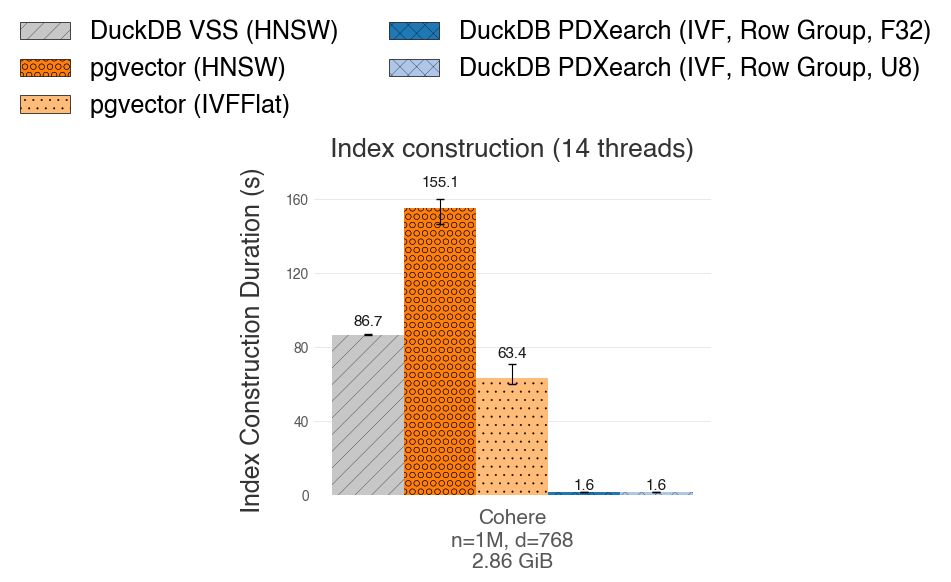

Saved index_creation_cohere_multi_thread.pdf


In [7]:
# ---------------------------------------------------------------------------
# 5. Cohere multi-thread only (standalone plot with own y-axis)
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

apply_style()

COHERE_THREADS = 14
cohere_datasets = [ds for ds in datasets if "Cohere" in ds]

# Group Cohere 14-thread records: dataset → index_type → list of durations
cohere_grouped: dict[str, dict[str, list[float]]] = defaultdict(lambda: defaultdict(list))
for r in records:
    if r["threads"] == COHERE_THREADS and "Cohere" in r["dataset"]:
        if "Global" in r["index"]:
            continue
        cohere_grouped[r["dataset"]][r["index"]].append(r["optimize_duration"])

# Index types present in Cohere data
cohere_index_types = set()
for ds in cohere_datasets:
    cohere_index_types.update(cohere_grouped[ds].keys())
cohere_index_types = [idx for idx in INDEX_ORDER if idx in cohere_index_types]
n_idx = len(cohere_index_types)

print(f"Cohere multi-thread ({COHERE_THREADS}T) index types: {n_idx}")
for ds in cohere_datasets:
    for idx in cohere_index_types:
        durs = cohere_grouped[ds].get(idx, [])
        if durs:
            print(f"  {ds} / {idx}: {len(durs)} runs, median={np.median(durs):.2f}s")

bar_width = 0.45
group_width = n_idx * bar_width + 0.2
group_spacing = 0.4

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

x_base = 0
x_labels = []
group_centers = []

for dataset in cohere_datasets:
    thread_data = cohere_grouped[dataset]
    if not any(thread_data.values()):
        continue

    group_start = x_base
    for idx_idx, index_type in enumerate(cohere_index_types):
        x = group_start + idx_idx * bar_width
        durations = thread_data.get(index_type, [])
        if durations:
            med_dur = float(np.median(durations))

            lo_err = med_dur - float(np.min(durations))

            hi_err = float(np.max(durations)) - med_dur
            color = index_colors.get(index_type, "#808080")
            hatch = index_hatches.get(index_type, "")
            ax.bar(x, med_dur, bar_width, yerr=[[lo_err], [hi_err]], color=color, hatch=hatch,
                   capsize=3, error_kw={"linewidth": 0.8})

            top = med_dur + hi_err
            offset = max(0.05, top * 0.03)
            ax.text(x, top + offset, f"{med_dur:.1f}",
                    ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE, color=BAR_TEXT_COLOR)

    dataset_label = format_dataset_label(dataset)
    x_labels.append(dataset_label)
    center = group_start + (n_idx - 1) * bar_width / 2
    group_centers.append(center)
    x_base += group_width + group_spacing

ax.set_title(f"Index construction ({COHERE_THREADS} threads)",
             fontsize=LABEL_FONTSIZE + 1, color=FONT_COLOR, pad=20)
ax.set_ylabel("Index Construction Duration (s)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

ax.set_xticks(group_centers)
ax.set_xticklabels(x_labels, fontsize=X_TICK_FONTSIZE, color=TICK_FONTS_COLOR)

ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(axis='y', colors=TICK_FONTS_COLOR)
ax.tick_params(axis='both', length=0)
ax.tick_params(axis='x', pad=10)

legend_handles = [
    Patch(facecolor=index_colors.get(idx, "#808080"),
          hatch=index_hatches.get(idx, ""),
          edgecolor='black', linewidth=0.5, label=idx)
    for idx in cohere_index_types
]
fig.legend(handles=legend_handles, loc="upper center", ncols=math.ceil(len(cohere_index_types) / 3),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.18))

fig.tight_layout(rect=[0, 0, 1, 0.93])
save_fig("index_creation_cohere_multi_thread")
plt.show()
print("Saved index_creation_cohere_multi_thread.pdf")